In [3]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

In [4]:
class calc_diag:
    def __init__(self,WRFFILELIST,trackdata,startindx,preslv,weshape,nsshape):
        self.WRFFILELIST = WRFFILELIST
        self.trackdata = trackdata
        self.startindx = startindx
        self.preslv = preslv
        self.weshape = weshape
        self.nsshape = nsshape

    def interp_to_preslv(self,vartointerp,prestointerp):
        nc_wp = [interplevel(vartointerp,prestointerp,i) for i in self.preslv]
        return np.asarray(nc_wp)
        
    def read_vars(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            varout.append(getvar(Dataset(self.WRFFILELIST[i]),varname))
        return np.asarray(varout)

    def read_vars_and_interp(self,varname):
        varout = []
        for i in range(len(self.WRFFILELIST)):
            vartointerp = getvar(Dataset(self.WRFFILELIST[i]),varname)
            prestointerp = getvar(Dataset(self.WRFFILELIST[i]),'pres')
            varout.append(self.interp_to_preslv(vartointerp,prestointerp))
        return np.asarray(varout)
        
    def find_track_ij(self):
        ixs,iys = [],[]
        for i, WRFFILE in tqdm(enumerate(self.WRFFILELIST)):
            # read file
            nc_ctrl = Dataset(WRFFILE)
            # Target location
            target_lat = self.trackdata['clat'][self.startindx+i] # Simulations start from 12 UTC
            target_lon = self.trackdata['clon'][self.startindx+i] # Simulations start from 12 UTC
            # Compute track indices
            ix, iy = ll_to_xy(nc_ctrl, target_lat, target_lon, timeidx=0) #x, y
            ixs.append(int(ix.values))
            iys.append(int(iy.values))
        return ixs,iys
        
    def compute_tc_shear(self, u, v, x0, y0, dx_km=3.0,
                     inner_km=200.0, outer_km=800.0,
                     p_top=200.0, p_bot=850.0):
        """
        Compute mean 200–850 hPa shear vector in a TC-centered annulus.

        Parameters
        ----------
        ds : netCDF Dataset (opened with netCDF4 or xarray + wrf-python)
            WRF output file handle
        x0, y0 : int
            TC center grid indices (x,y) in WRF domain
        dx_km : float
            Grid spacing (km)
        inner_km, outer_km : float
            Inner and outer radius of annulus (km)
        p_top, p_bot : float
            Top and bottom pressure levels (hPa)

        Returns
        -------
        shear_u, shear_v : floats
            Zonal and meridional shear components (m/s)
        shear_mag : float
            Shear magnitude (m/s)
        """

        # --- Interpolate to levels
        u200 = u[self.preslv.index(p_top),...]
        v200 = v[self.preslv.index(p_top),...]
        u850 = u[self.preslv.index(p_bot),...]
        v850 = v[self.preslv.index(p_bot),...]

        # --- Make distance mask in km
        ny, nx = u200.shape
        X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
        dx = (X - x0) * dx_km
        dy = (Y - y0) * dx_km
        r = np.sqrt(dx**2 + dy**2)

        mask = (r >= inner_km) & (r <= outer_km)

        # --- Area-average wind in annulus
        u200m = np.nanmean(np.where(mask, u200, np.nan))
        v200m = np.nanmean(np.where(mask, v200, np.nan))
        u850m = np.nanmean(np.where(mask, u850, np.nan))
        v850m = np.nanmean(np.where(mask, v850, np.nan))

        # --- Shear vector
        shear_u = u200m - u850m
        shear_v = v200m - v850m
        shear_mag = np.sqrt(shear_u**2 + shear_v**2)

        return shear_u, shear_v, shear_mag

    def get_shear_mag_dir(self,Upres,Vpres,Xs,ys,settings=[200.0,800.0,200.0,850.0,3.0]):
        """
        settings = [inner_km,outer_km,p_top,p_bot,dx_km]
        """
        shear_mags,shear_dirs = [],[]
        shear_us, shear_vs = [],[]
        for i in range(len(Xs)):
            radiusshape = int(settings[1]/settings[4])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                shear_mags.append(np.nan)
                shear_dirs.append(np.nan)
                shear_us.append(np.nan)
                shear_vs.append(np.nan)
            else:
                shear_u, shear_v, shear_mag = self.compute_tc_shear(Upres[i,...], Vpres[i,...], Xs[i], ys[i], 
                                                                       dx_km=settings[4],
                                                                       inner_km=settings[0], outer_km=settings[1],
                                                                       p_top=settings[2], p_bot=settings[3])
                shear_mags.append(shear_mag)
                shear_dirs.append((np.degrees(np.arctan2(shear_v, shear_u)) % 360.0))
                shear_us.append(shear_u)
                shear_vs.append(shear_v)
        return shear_mags,shear_dirs, shear_vs, shear_us

    def data_to_TCcentre(self,data,Xs,ys,settings=[800.0,3.0,200.0]):
        dataTC = []
        for i in range(len(Xs)):
            radiusshape = int(settings[0]/settings[1])
            if ((self.weshape-Xs[i])>radiusshape) and ((self.nsshape-ys[i])>radiusshape):
                dataTC.append(np.nan)
            else:
                domainint = int(settings[2])
                dataTC.append(data[i,:,ys[i]-domainint:ys[i]+domainint,Xs[i]-domainint:Xs[i]+domainint])
        return np.asarray(dataTC)
            
    def data_to_polar(self,Cnc_wpz,dx,rmax,dr,nazim):        
        # Convert to polar coordinates
        # Suppose Xtrain_n shape = (n_samples, 9, ny, nx)
        ny, nx = Cnc_wpz.shape[-2:]
        if len(Cnc_wpz.shape)>3:
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpz, tri, pts, target_points, r, az)
        elif len(Cnc_wpz.shape)==3:
            Cnc_wpza = np.expand_dims(Cnc_wpz, axis=1)
            tri, pts, target_points, r, az = to_polar.precompute_cartesian_to_polar_map(
                nx=nx, ny=ny, dx=dx, rmax=rmax, dr=dr, nazim=nazim
            )
            return to_polar.fast_cartesian_to_polar_batch(Cnc_wpza, tri, pts, target_points, r, az)

In [6]:
def get_proc_data_polar(track,ctrl_files,wantvar='rh'):    
    etalevels,weshape,nsshape = getvar(Dataset(ctrl_files[0]),'pres').shape
    wrfdiags = calc_diag(ctrl_files,track_memb03,12,[10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000],weshape,nsshape)
    tracks_ij = wrfdiags.find_track_ij()

    # Shear calculation
    Upres,Vpres = wrfdiags.read_vars_and_interp('ua'), wrfdiags.read_vars_and_interp('va')

    shear_mags,shear_dirs,shear_uv,shear_vs = wrfdiags.get_shear_mag_dir(Upres,Vpres,tracks_ij[0],
                                                                         tracks_ij[1],
                                                                         settings=[200.0,800.0,int(200.0*100),int(850.0*100),3.0])
    # Calculate polar version of one variable
    RHpres = wrfdiags.read_vars_and_interp(wantvar)
    RHpres_ctre = wrfdiags.data_to_TCcentre(RHpres,tracks_ij[0],tracks_ij[1])
    RHpres_plr = wrfdiags.data_to_polar(RHpres_ctre,3,600,3,360)
    return {'trackkij':tracks_ij,'shearmags':shear_mags,'sheardirs':shear_dirs,'varcart':RHpres_ctre,'varpol':RHpres_plr}

In [7]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

sens2x_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add2wv1N/wrfout_d02_2013-11-0*"))[:6]
ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:6]
#sens1x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_wv1N/wrfout_d02_2013-11-0*"))[:30]
minus2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/minus_2wv1N/wrfout_d02_2013-11-0*"))[:6]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/add_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:6]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:6]

## RH

In [9]:
ctrl_rh = get_proc_data_polar(track_memb03,ctrl_files,wantvar='rh')
sens2x_rh = get_proc_data_polar(track_memb03,sens2x_files,wantvar='rh')
minus2x_rh = get_proc_data_polar(track_memb03,minus2x_files,wantvar='rh')
dd_p2f_rh = get_proc_data_polar(track_memb03,dd_p2f_files,wantvar='rh')
mdd_p2f_rh = get_proc_data_polar(track_memb03,mdd_p2f_files,wantvar='rh')

6it [00:00, 25.23it/s]
100%|██████████| 6/6 [00:02<00:00,  2.62it/s]
6it [00:00, 12.49it/s]
100%|██████████| 6/6 [00:02<00:00,  2.78it/s]
6it [00:00, 13.71it/s]
100%|██████████| 6/6 [00:02<00:00,  2.93it/s]
6it [00:00, 15.16it/s]
100%|██████████| 6/6 [00:02<00:00,  2.87it/s]
6it [00:00, 11.52it/s]
100%|██████████| 6/6 [00:02<00:00,  2.70it/s]


In [11]:
ctrl_rh_rota = np.asarray([np.roll(ctrl_rh['varpol'][i],shift=-int(ctrl_rh['sheardirs'][i]), axis=-1) for i in range(6)])
sens2x_rh_rota = np.asarray([np.roll(sens2x_rh['varpol'][i],shift=-int(sens2x_rh['sheardirs'][i]), axis=-1) for i in range(6)])
minus2x_rh_rota = np.asarray([np.roll(minus2x_rh['varpol'][i],shift=-int(minus2x_rh['sheardirs'][i]), axis=-1) for i in range(6)])
dd_p2f_rh_rota = np.asarray([np.roll(dd_p2f_rh['varpol'][i],shift=-int(dd_p2f_rh['sheardirs'][i]), axis=-1) for i in range(6)])
mdd_p2f_rh_rota = np.asarray([np.roll(mdd_p2f_rh['varpol'][i],shift=-int(mdd_p2f_rh['sheardirs'][i]), axis=-1) for i in range(6)])

In [33]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 10,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_16914/4003527188.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [40]:
dd_p2f_rh_rota[-1].shape

(11, 200, 360)

In [43]:
DD_P2F_RH_axim = np.mean((dd_p2f_rh_rota[-1]-dd_p2f_rh_rota[0])/6,axis=-1)
CTRL_RH_axim = np.mean((ctrl_rh_rota[-1]-ctrl_rh_rota[0])/6,axis=-1)
SENS2X_RH_axim = np.mean((sens2x_rh_rota[-1]-sens2x_rh_rota[0])/6,axis=-1)

DD_P2F_RH_upshear = np.mean((dd_p2f_rh_rota[-1][:,:,90:270]-dd_p2f_rh_rota[0][:,:,90:270])/6,axis=-1)
CTRL_RH_upshear = np.mean((ctrl_rh_rota[-1][:,:,90:270]-ctrl_rh_rota[0][:,:,90:270])/6,axis=-1)
SENS2X_RH_upshear = np.mean((sens2x_rh_rota[-1][:,:,90:270]-sens2x_rh_rota[0][:,:,90:270])/6,axis=-1)

dd_p2f_dshear = np.concatenate([dd_p2f_rh_rota[:,:,:,0:90],dd_p2f_rh_rota[:,:,:,270:]],axis=-1)
ctrl_dshear = np.concatenate([ctrl_rh_rota[:,:,:,0:90],ctrl_rh_rota[:,:,:,270:]],axis=-1)
sens2x_dshear = np.concatenate([sens2x_rh_rota[:,:,:,0:90],sens2x_rh_rota[:,:,:,270:]],axis=-1)

DD_P2F_RH_downshear = np.mean((dd_p2f_dshear[-1][:,:,:]-dd_p2f_dshear[0][:,:,:])/6,axis=-1)
CTRL_RH_downshear = np.mean((ctrl_dshear[-1][:,:,:]-ctrl_dshear[0][:,:,:])/6,axis=-1)
SENS2X_RH_downshear = np.mean((sens2x_dshear[-1][:,:,:]-sens2x_dshear[0][:,:,:])/6,axis=-1)

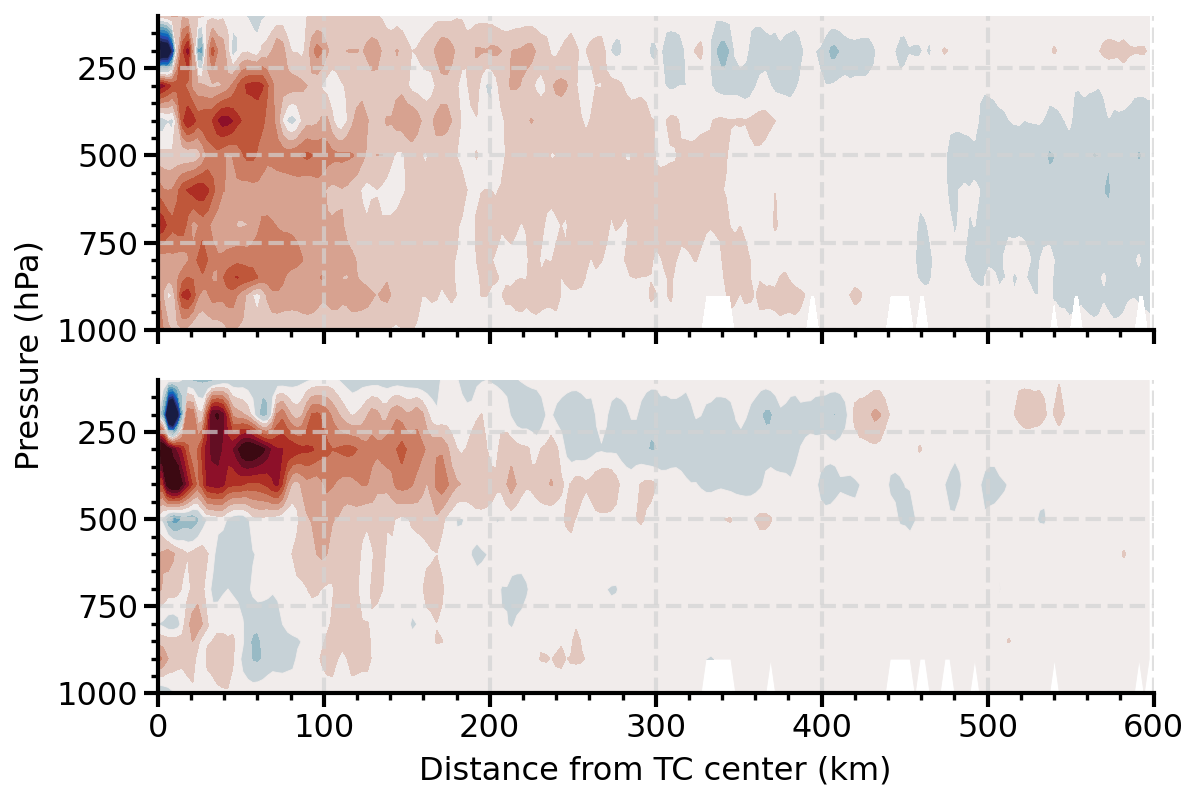

In [38]:
fig, axs = plot.subplots(ncols=1, nrows=2, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    DD_P2F_RH_axim-CTRL_RH_axim,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    SENS2X_RH_axim-CTRL_RH_axim,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

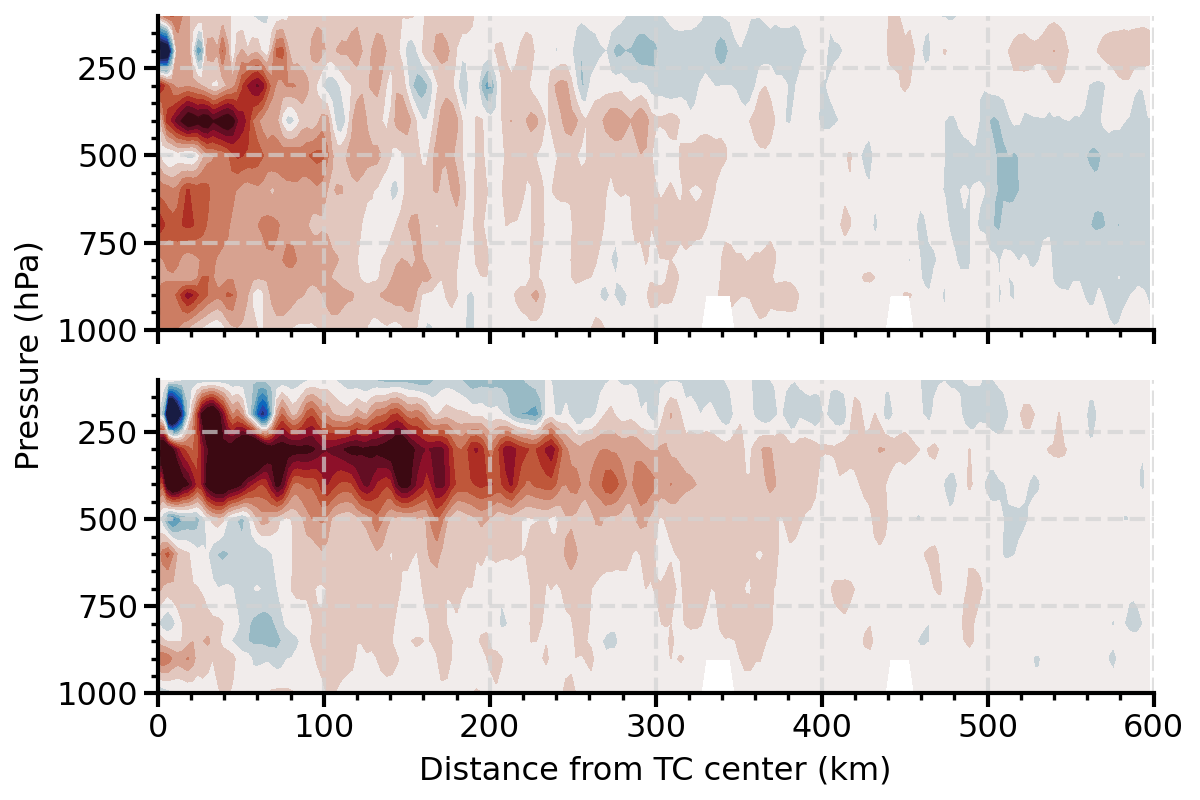

In [42]:
fig, axs = plot.subplots(ncols=1, nrows=2, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    DD_P2F_RH_upshear-CTRL_RH_upshear,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    SENS2X_RH_upshear-CTRL_RH_upshear,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

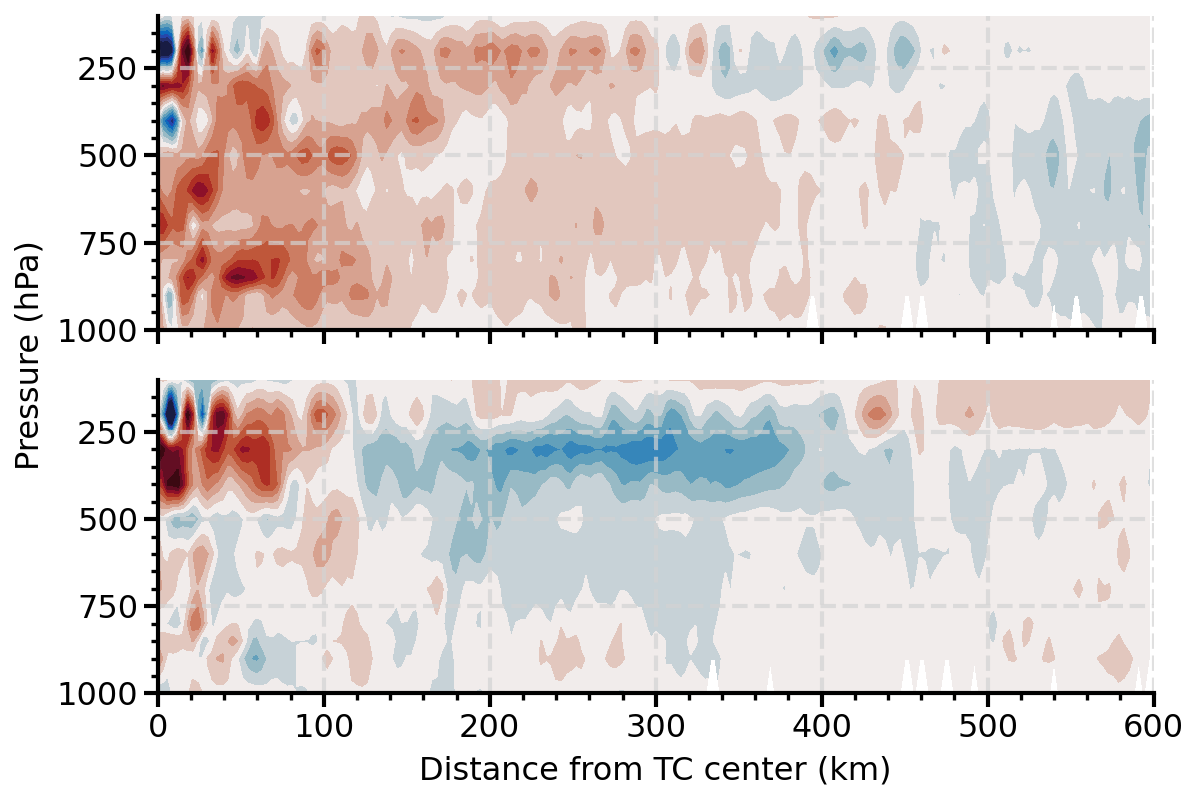

In [44]:
fig, axs = plot.subplots(ncols=1, nrows=2, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    DD_P2F_RH_downshear-CTRL_RH_downshear,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    SENS2X_RH_downshear-CTRL_RH_downshear,cmap='balance',levels=np.linspace(-1.5,1.5,16),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

 ## Vertical Velocity

In [45]:
ctrl_wa = get_proc_data_polar(track_memb03,ctrl_files,wantvar='wa')
sens2x_wa = get_proc_data_polar(track_memb03,sens2x_files,wantvar='wa')
minus2x_wa = get_proc_data_polar(track_memb03,minus2x_files,wantvar='wa')
dd_p2f_wa = get_proc_data_polar(track_memb03,dd_p2f_files,wantvar='wa')
mdd_p2f_wa = get_proc_data_polar(track_memb03,mdd_p2f_files,wantvar='wa')

6it [00:00, 11.69it/s]
100%|██████████| 6/6 [00:02<00:00,  2.64it/s]
6it [00:00, 11.83it/s]
100%|██████████| 6/6 [00:02<00:00,  2.43it/s]
6it [00:00, 14.38it/s]
100%|██████████| 6/6 [00:02<00:00,  3.00it/s]
6it [00:00, 13.13it/s]
100%|██████████| 6/6 [00:02<00:00,  2.60it/s]
6it [00:00, 12.55it/s]
100%|██████████| 6/6 [00:01<00:00,  3.59it/s]


In [47]:
ctrl_wa_rota = np.asarray([np.roll(ctrl_wa['varpol'][i],shift=-int(ctrl_wa['sheardirs'][i]), axis=-1) for i in range(6)])
sens2x_wa_rota = np.asarray([np.roll(sens2x_wa['varpol'][i],shift=-int(sens2x_wa['sheardirs'][i]), axis=-1) for i in range(6)])
minus2x_wa_rota = np.asarray([np.roll(minus2x_wa['varpol'][i],shift=-int(minus2x_wa['sheardirs'][i]), axis=-1) for i in range(6)])
dd_p2f_wa_rota = np.asarray([np.roll(dd_p2f_wa['varpol'][i],shift=-int(dd_p2f_wa['sheardirs'][i]), axis=-1) for i in range(6)])
mdd_p2f_wa_rota = np.asarray([np.roll(mdd_p2f_wa['varpol'][i],shift=-int(mdd_p2f_wa['sheardirs'][i]), axis=-1) for i in range(6)])

In [57]:
DD_P2F_wa_axim = np.mean((dd_p2f_wa_rota[-1]-dd_p2f_wa_rota[0])/6,axis=-1)
CTRL_wa_axim = np.mean((ctrl_wa_rota[-1]-ctrl_wa_rota[0])/6,axis=-1)
SENS2X_wa_axim = np.mean((sens2x_wa_rota[-1]-sens2x_wa_rota[0])/6,axis=-1)

DD_P2F_wa_upshear = np.mean((dd_p2f_wa_rota[-1][:,:,90:270]-dd_p2f_wa_rota[0][:,:,90:270])/6,axis=-1)
CTRL_wa_upshear = np.mean((ctrl_wa_rota[-1][:,:,90:270]-ctrl_wa_rota[0][:,:,90:270])/6,axis=-1)
SENS2X_wa_upshear = np.mean((sens2x_wa_rota[-1][:,:,90:270]-sens2x_wa_rota[0][:,:,90:270])/6,axis=-1)

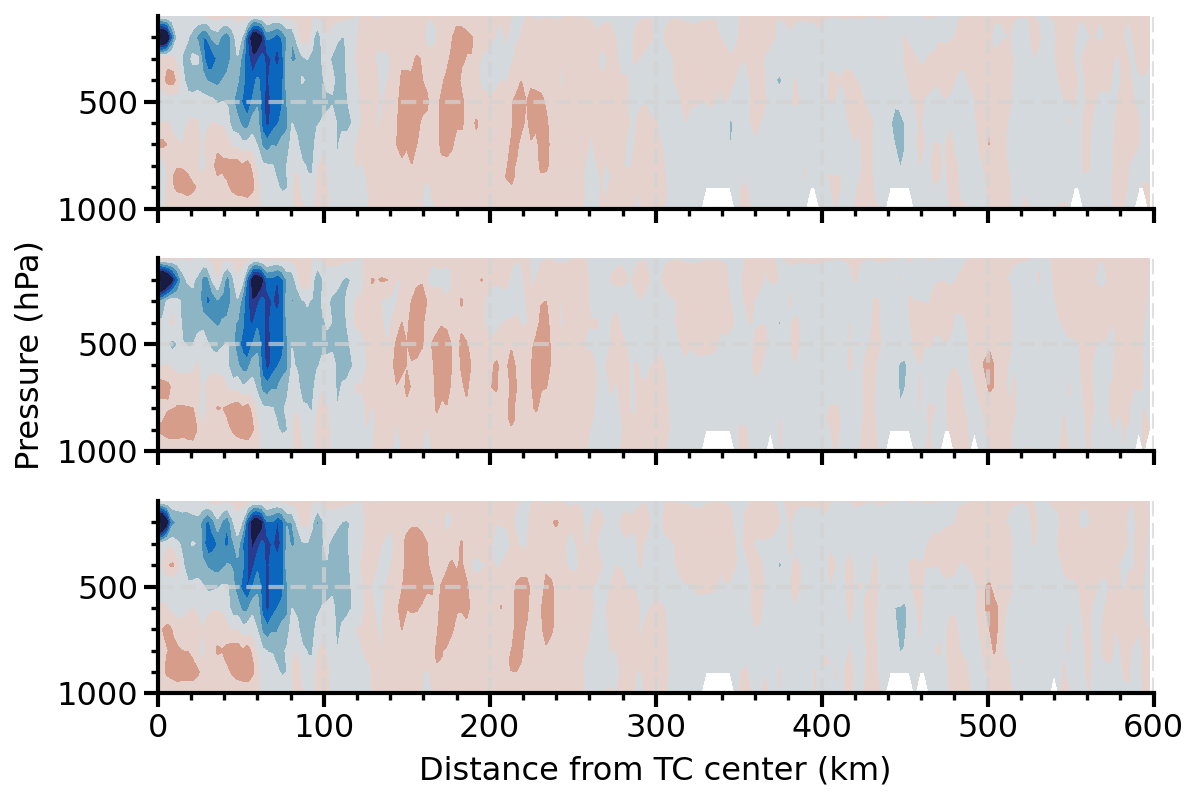

In [56]:
fig, axs = plot.subplots(ncols=1, nrows=3, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    DD_P2F_wa_axim,cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    SENS2X_wa_axim,cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[2].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    CTRL_wa_axim,cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

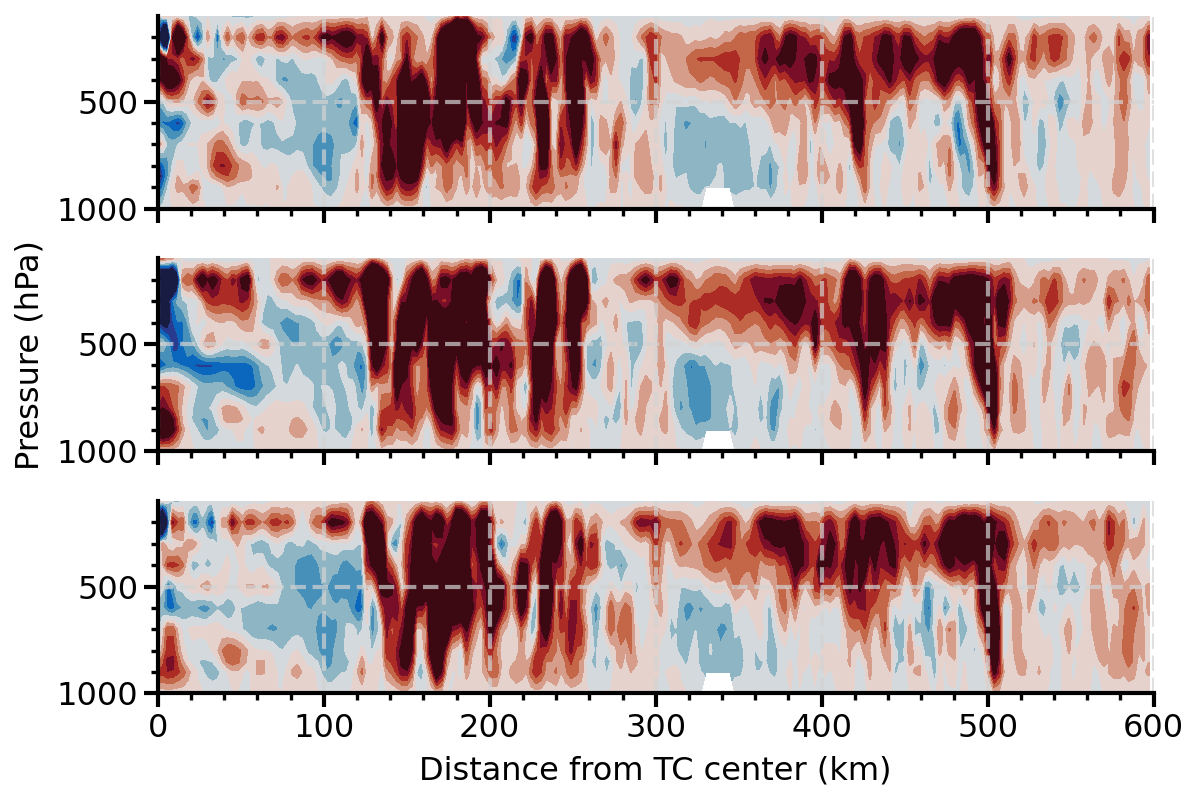

In [59]:
fig, axs = plot.subplots(ncols=1, nrows=3, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(dd_p2f_wa_rota[-1][:,:,90:270],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(sens2x_wa_rota[-1][:,:,90:270],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[2].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(ctrl_wa_rota[-1][:,:,90:270],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()

In [60]:
dd_p2f_wa_dshear = np.concatenate([dd_p2f_wa_rota[:,:,:,0:90],dd_p2f_wa_rota[:,:,:,270:]],axis=-1)
ctrl_wa_dshear = np.concatenate([ctrl_wa_rota[:,:,:,0:90],ctrl_wa_rota[:,:,:,270:]],axis=-1)
sens2x_wa_dshear = np.concatenate([sens2x_wa_rota[:,:,:,0:90],sens2x_wa_rota[:,:,:,270:]],axis=-1)

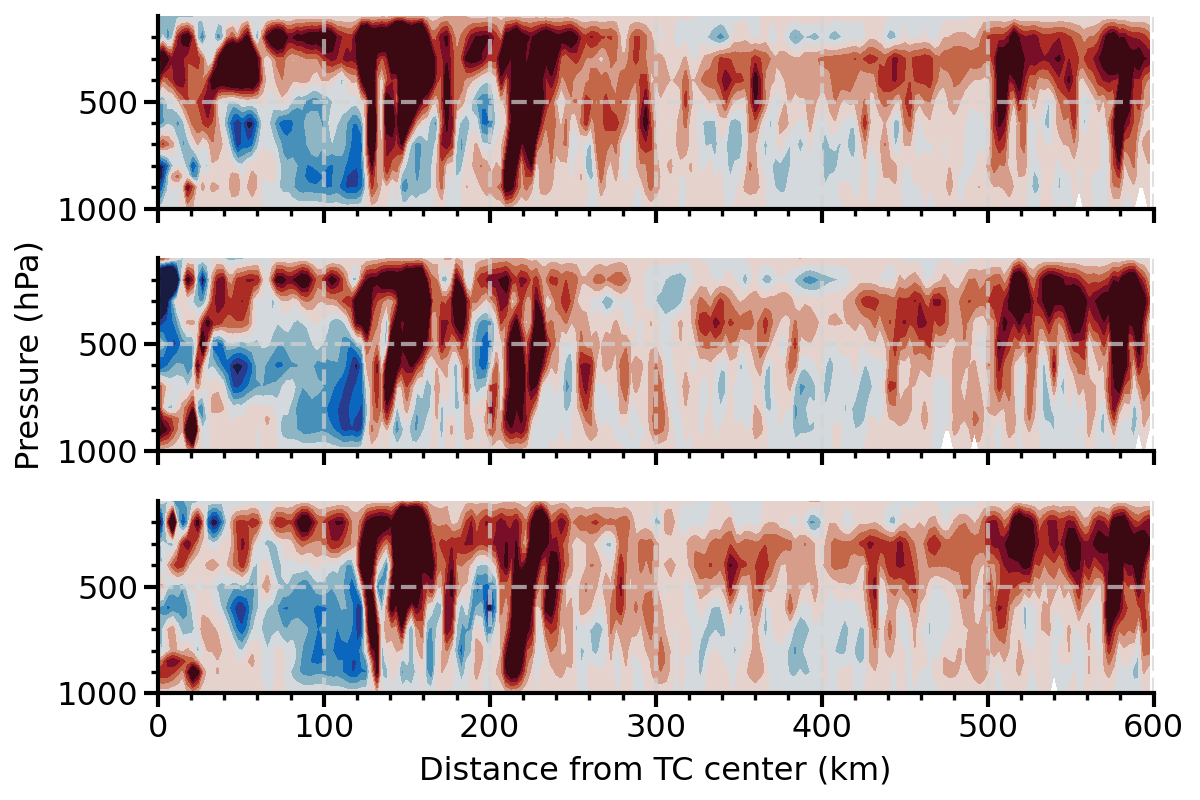

In [61]:
fig, axs = plot.subplots(ncols=1, nrows=3, figsize=(6,4), share=True)
axs[0].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(dd_p2f_wa_dshear[-1],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[1].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(sens2x_wa_dshear[-1],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs[2].contourf(np.linspace(0,199,200)*3,
    np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])/100,
    np.mean(ctrl_wa_dshear[-1],axis=-1),cmap='balance',levels=np.linspace(-0.1,0.1,11),extend='both')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance from TC center (km)', ylabel='Pressure (hPa)')
#plt.savefig('./pics/conv_memb3.png',dpi=400)
plt.show()